# Evaluations

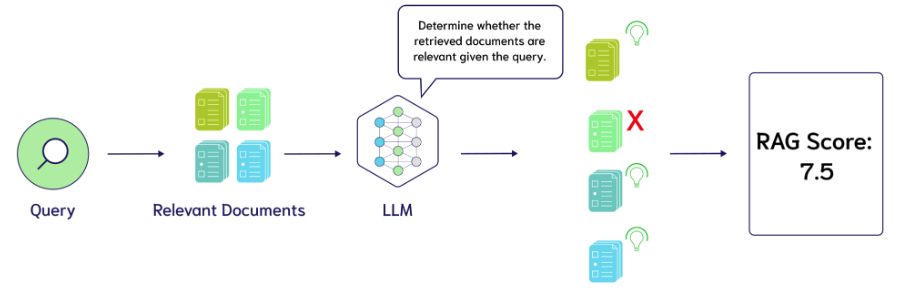

# [RAGAs - Evaluations](https://docs.ragas.io/en/stable/)

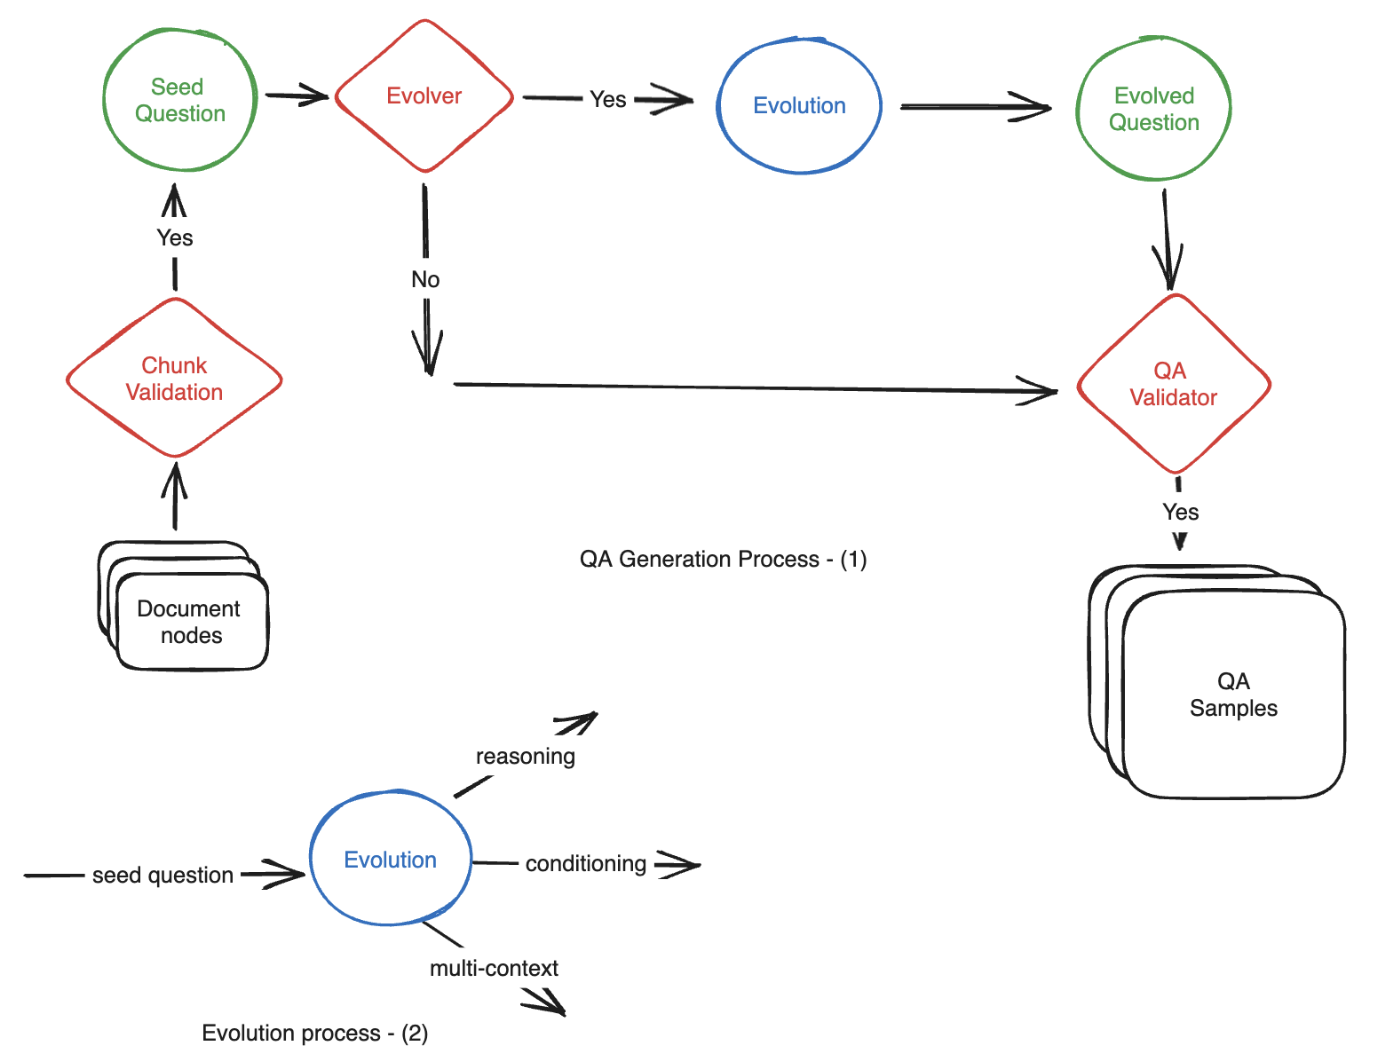

## [평가 데이터셋 생성](https://docs.ragas.io/en/latest/concepts/test_data_generation/)

### 문서 전처리

In [1]:
from langchain_community.document_loaders import PDFPlumberLoader

# 문서 로더 생성
DATA_PATH = "./data/"
loader = PDFPlumberLoader(DATA_PATH+"SPRI_AI_Brief_2023년12월호_F.pdf")

# 문서 로딩
documents = loader.load()

In [2]:
print(f"PDF 페이지 수: {len(documents)}")

PDF 페이지 수: 23


> PDF 파일 내용

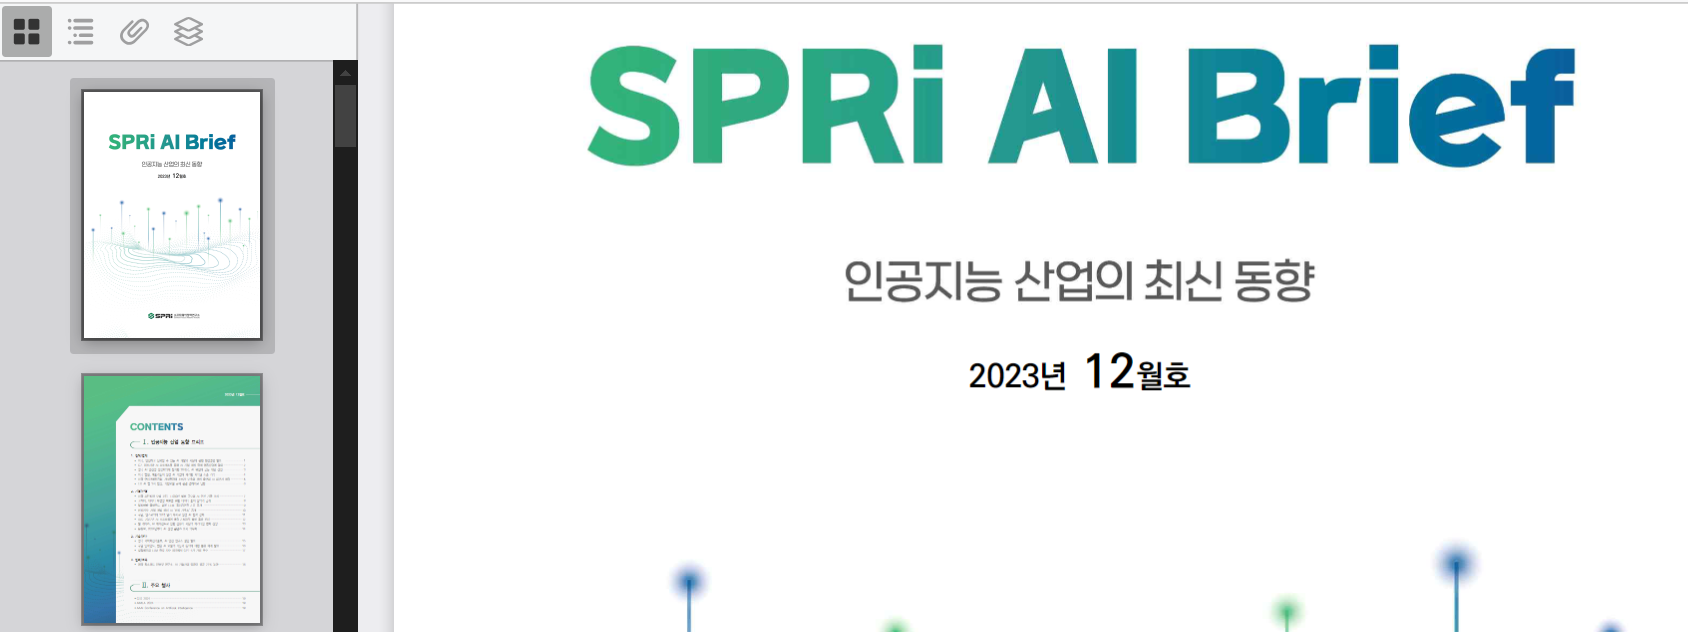

In [3]:
# 시작, 목차, 끝 페이지 제외
documents = documents[3:-1]

# 문서의 페이지수
len(documents)

19

> metadata 처리 

In [4]:
documents[0].metadata

{'source': './data/SPRI_AI_Brief_2023년12월호_F.pdf',
 'file_path': './data/SPRI_AI_Brief_2023년12월호_F.pdf',
 'page': 3,
 'total_pages': 23,
 'Author': 'dj',
 'Creator': 'Hwp 2018 10.0.0.13462',
 'Producer': 'Hancom PDF 1.3.0.542',
 'CreationDate': "D:20231208132838+09'00'",
 'ModDate': "D:20231208132838+09'00'",
 'PDFVersion': '1.4'}

In [5]:
# metadata 설정(filename 이 존재해야 함)
for doc in documents:
    doc.metadata["source"] = f"file path: {doc.metadata["file_path"]} & page no: {doc.metadata['page']}"


In [6]:
documents[0].metadata

{'source': 'file path: ./data/SPRI_AI_Brief_2023년12월호_F.pdf & page no: 3',
 'file_path': './data/SPRI_AI_Brief_2023년12월호_F.pdf',
 'page': 3,
 'total_pages': 23,
 'Author': 'dj',
 'Creator': 'Hwp 2018 10.0.0.13462',
 'Producer': 'Hancom PDF 1.3.0.542',
 'CreationDate': "D:20231208132838+09'00'",
 'ModDate': "D:20231208132838+09'00'",
 'PDFVersion': '1.4'}

> page_content 확인 

In [7]:
print(documents[0].page_content[:300])

1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육
미국, 안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령 발표
KEY Contents
n 미국 바이든 대통령이 ‘안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령’에 서명하고
광범위한 행정 조치를 명시
n 행정명령은 △AI의 안전과 보안 기준 마련 △개인정보보호 △형평성과 시민권 향상 △소비자
보호 △노동자 지원 △혁신과 경쟁 촉진 △국제협력을 골자로 함
£바이든 대통령, AI 행정명령 통해 안전하고 신뢰할 수 있는 AI 개발과 활용 추진
n 미국 바


### 평가 데이터셋

#### [문장을 생성하는 LLM](https://platform.openai.com/docs/models)

In [8]:
from dotenv import load_dotenv 

# .env 파일에 있는 데이터를 환경변수에 등록해주는 함수 
load_dotenv()

True

In [9]:
# Langchain LLM 객체를 ragas가 인식할 수 있게 변형
# Wrapper -> 감싸다. 또는 형변환 된다...
from ragas.llms import LangchainLLMWrapper
# Langchain에서 인식할 수 있는 OpenaAI LLM 객체
from langchain_openai import ChatOpenAI

# 문장을 생성하는 LLM -> 질문 & 답변 생성을 목적으로...
generator_llm = LangchainLLMWrapper(ChatOpenAI(
    model="gpt-4o-mini"
))

C:\Users\Playdata\AppData\Local\Temp\ipykernel_6352\211073525.py:8: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  generator_llm = LangchainLLMWrapper(ChatOpenAI(


#### [Embedding model](https://platform.openai.com/docs/guides/embeddings/embedding-models#embedding-models)

In [10]:
# RAGAs의 최신 OpenAIEmbeddings 사용 (client 필요)
from ragas.embeddings import OpenAIEmbeddings
from openai import OpenAI

# Embedding model -> 문장을 벡터로 변환하는 모델...
generator_embeddings = OpenAIEmbeddings(
    # OpenAI client 생성 (환경변수의 OPENAI_API_KEY를 자동으로 사용)
    client=OpenAI(),
    model="text-embedding-3-small"
)

#### 페르소나 정의(중요)
> 어떤 질문/답변 쌍을 만들지 정의함 

In [11]:
from ragas.testset.persona import Persona

personas = [
    Persona(
        name="AI Specialist",
        # 대규모 언어 모델(LLM)이 생성한 응답이 논리적으로 일관성 있고 윤리적으로 타당한지 평가하는 전문가.
        role_description=""""
        A professional who evaluates whether the responses generated by large language models (LLMs) are logically coherent and ethically sound.
        """,
    ),
]

#### 학습용 데이터를 만드는 객체

In [12]:
from ragas.testset import TestsetGenerator

# 학습용 데이터를 만드는 객체
generator = TestsetGenerator(
    llm=generator_llm, embedding_model=generator_embeddings, 
    persona_list=personas
)

NERExtractor: 
> RAG 평가용 테스트셋 생성 시, 문서에 등장하는 핵심 엔티티를 뽑아 질문을 자동 생성하는 클래스입니다.

In [13]:
from ragas.testset.transforms.extractors.llm_based import NERExtractor

transforms = [NERExtractor(llm=generator_llm)]

SingleHopSpecificQuerySynthesizer
> Ragas의 테스트셋 생성 기능에서, 단일 문서 기반(single-hop)으로 “특정하고 구체적인 질문”을 자동 생성하는 Synthesizer 클래스입니다.

In [14]:
from ragas.testset.synthesizers.single_hop.specific import (
    SingleHopSpecificQuerySynthesizer
)

distribution = [
    (SingleHopSpecificQuerySynthesizer(llm=generator_llm), 1.0),
]

for query, _ in distribution:
    prompts = await query.adapt_prompts("korean", llm=generator_llm)
    query.set_prompts(**prompts)

#### 평가 데이터셋 생성

In [15]:
dataset = generator.generate_with_langchain_docs(
    documents[:],
    testset_size=10, # 총 몇개의 질문/답변 쌍을 만들지
    transforms=transforms,
    query_distribution=distribution,
)

Applying NERExtractor:   0%|          | 0/19 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/1 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/10 [00:00<?, ?it/s]

#### 생성된 데이터셋 확인

In [16]:
eval_dataset = dataset.to_evaluation_dataset()

In [17]:
print("Query:", eval_dataset[0].user_input)
print("Reference:", eval_dataset[0].reference)

Query: 바이든 대통령이 발표한 AI 행정명령의 주요 내용은 뭐고, 그 목적은 무엇인지 설명해줘.
Reference: 바이든 대통령이 발표한 AI 행정명령은 안전하고 신뢰할 수 있는 AI 개발과 사용을 보장하기 위한 것으로, 주요 내용은 AI의 안전과 보안 기준 마련, 개인정보보호, 형평성과 시민권 향상, 소비자 보호, 노동자 지원, 혁신과 경쟁 촉진, 국제협력 등을 포함합니다. 이 행정명령의 목적은 AI 시스템의 안전성과 신뢰성을 확인하고, AI의 무책임한 사용으로 인한 차별과 편견을 방지하며, AI 기술을 통해 소비자와 근로자를 보호하고, 미국 전역의 AI 연구를 촉진하는 것입니다.


In [18]:
# 생성된 테스트셋을 pandas DataFrame으로 변환
test_df = eval_dataset.to_pandas()
test_df.shape

(10, 6)

In [19]:
test_df.head(2)

,user_input,reference_contexts,reference,persona_name,query_style,query_length
0,"바이든 대통령이 발표한 AI 행정명령의 주요 내용은 뭐고, 그 목적은 무엇인지 설명해줘.","[1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육\n미국, 안전하고...",바이든 대통령이 발표한 AI 행정명령은 안전하고 신뢰할 수 있는 AI 개발과 사용을...,AI Specialist,POOR_GRAMMAR,LONG
1,G7이 히로시마 AI 프로세스를 통해 AI 기업을 대상으로 마련한 국제 행동강령의 ...,"[SPRi AI Brief |\n2023-12월호\nG7, 히로시마 AI 프로세스를...",G7은 AI 기업을 대상으로 AI 위험 식별과 완화를 위해 자발적인 채택을 권고하는...,AI Specialist,PERFECT_GRAMMAR,LONG


#### 저장 

In [ ]:
test_df.to_csv("./data/evaluation_ragas.csv", index=False, header=True)